# Does nuclear morphology track CRC progression? The AKPS isogenic series

**Question:** the paper's main classification analysis (see
`classification_investigation.ipynb`) trains models to distinguish healthy
(P021N) from tumor (P013T) organoids. This notebook asks a different, arguably
more important question (flagged by Joshua's supervisor as the priority
dataset): **does a "tumor-likeness" score learned from that binary task track
the actual mutational progression** in the isogenic AKPS series (Drost et al.
2015)?

The AKPS series shares one genetic background and adds mutations cumulatively
along the classic CIN adenoma-to-carcinoma pathway:

| Line | Mutations added |
|---|---|
| **NCO** | none (wild-type normal colon organoid) |
| **A** | APC-KO (constant Wnt activation) |
| **AK** | + KRAS-G12D (EGFR-pathway / cell-cycle drive) |
| **AKP** | + TP53-KO (loss of DNA-damage response) |
| **AKPS** | + SMAD4-KO (loss of TGF-beta signaling) |

**Design:** since no manual ground-truth segmentation exists for the AKPS
series (only automated CellposeSAM masks), we train the healthy-vs-tumor
classifier on the P021N/P013T data and score AKPS organoids with it. To check
robustness we use **three different training sources**: manual (ground-truth)
P021N/P013T segmentations, automated P021N/P013T segmentations, and the two
pooled together. All features (for P021N/P013T *and* AKPS) are computed by the
same self-contained extractor (`analysis/extract_features.py`) used in
Section 6 of the main notebook, so the comparison isn't confounded by
differing feature-computation formulas between datasets.

Per the earlier session finding, we focus on **`l0l2_logreg`** (the
interpretable, feature-selecting logistic regression) as the primary model —
not because it strictly maximizes AUC over plain `logreg`, but because
identifying *which* morphology features drive the progression trend is the
actual scientific payoff here.


In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from IPython.display import Image, display, Markdown

from analysis.akps_progression import (
    load_manual, load_auto, load_akps, run_all, LINE_ORDER, LINE_LABELS, FEATURE_COLS,
    _aggregate_organoid,
)
from analysis.models import l0l2_logreg_model

mpl.rcParams.update({
    'font.size': 11, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.0, 'figure.dpi': 150,
})
RESULTS_DIR = Path('../results/classification')
pd.set_option('display.float_format', lambda x: f'{x:.3f}')


## 1. Data

Features computed identically for both domains (manual/auto) and for AKPS.

In [2]:
manual = load_manual('../data/manual_vs_auto/manual_features.csv')
auto = load_auto('../data/manual_vs_auto/auto_trial005_FULL_features.csv')
combined = pd.concat([manual, auto], ignore_index=True)
akps = load_akps('../data/manual_vs_auto/akps_features.csv')

train_sets = {'manual': manual, 'auto': auto, 'manual+auto': combined}

summary_counts = pd.DataFrame([
    {'dataset': 'manual (P021N/P013T)', 'n_nuclei': len(manual), 'n_organoids': manual['organoid'].nunique()},
    {'dataset': 'auto (P021N/P013T)', 'n_nuclei': len(auto), 'n_organoids': auto['organoid'].nunique()},
    {'dataset': 'AKPS (all 5 lines, auto)', 'n_nuclei': len(akps), 'n_organoids': akps['organoid'].nunique()},
])
summary_counts


,dataset,n_nuclei,n_organoids
0,manual (P021N/P013T),347,22
1,auto (P021N/P013T),2181,92
2,"AKPS (all 5 lines, auto)",6656,220


In [3]:
akps.groupby('line')['organoid'].nunique().reindex(LINE_ORDER).rename('n_organoids').to_frame()


,n_organoids
line,
NCO,50
A,42
AK,46
AKP,40
AKPS,42


## 2. Does the "tumor score" track progression stage?

For each of the 3 training sources x 2 models x 3 aggregation levels, we fit on
P021N/P013T and score every AKPS organoid's predicted P(tumor). We then test
for a monotonic trend across NCO -> A -> AK -> AKP -> AKPS with Spearman's rank
correlation (ordinal stage index vs. tumor score, at organoid granularity).


In [4]:
scores, summary = run_all(train_sets, akps)
scores.to_csv(RESULTS_DIR / 'akps_scores.csv', index=False)
summary.to_csv(RESULTS_DIR / 'akps_summary.csv', index=False)
summary.sort_values('spearman_rho', ascending=False)


,train_set,model,mode,spearman_rho,spearman_p,mean_NCO,mean_A,mean_AK,mean_AKP,mean_AKPS
11,auto,l0l2_logreg,organoid_data_agg,0.835,0.000,0.343,0.534,0.600,0.852,0.917
2,manual,logreg,organoid_data_agg,0.831,0.000,0.046,0.289,0.390,0.927,0.954
8,auto,logreg,organoid_data_agg,0.830,0.000,0.208,0.837,0.792,0.983,0.988
14,manual+auto,logreg,organoid_data_agg,0.815,0.000,0.208,0.845,0.788,0.981,0.986
17,manual+auto,l0l2_logreg,organoid_data_agg,0.797,0.000,0.176,0.818,0.726,0.971,0.979
5,manual,l0l2_logreg,organoid_data_agg,0.797,0.000,0.531,0.535,0.537,0.548,0.553
16,manual+auto,l0l2_logreg,organoid_pred_agg,0.634,0.000,0.532,0.717,0.676,0.739,0.746
7,auto,logreg,organoid_pred_agg,0.625,0.000,0.497,0.789,0.727,0.817,0.832
13,manual+auto,logreg,organoid_pred_agg,0.624,0.000,0.472,0.785,0.715,0.813,0.830
1,manual,logreg,organoid_pred_agg,0.479,0.000,0.372,0.814,0.702,0.823,0.868


### Figure 1 — Progression trend, organoid-level, l0l2_logreg

Each panel trains on a different feature source; points are individual
organoids (jittered), the black line is the mean +/- SEM per stage.


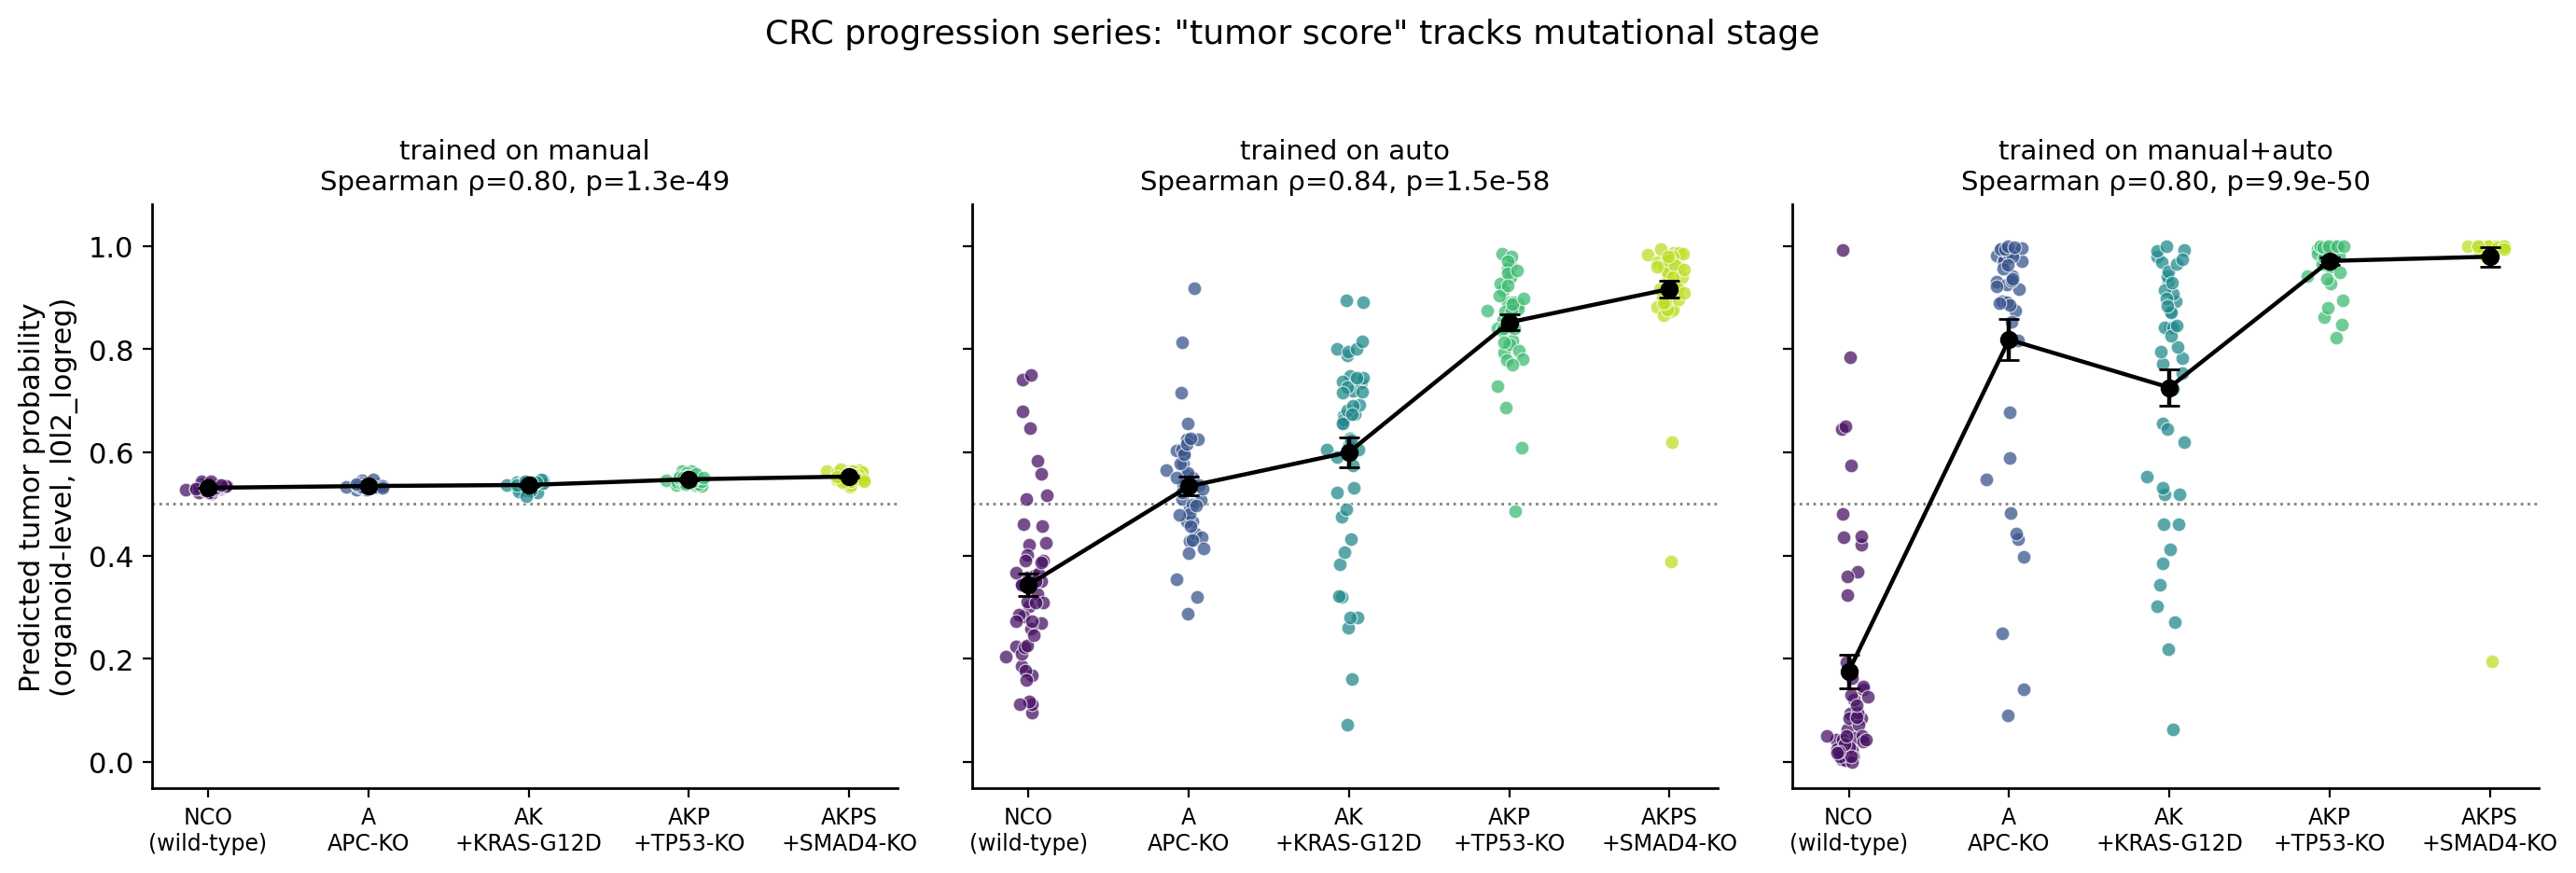

In [5]:
display(Image(filename=str(RESULTS_DIR / 'akps_trend_plot.png')))


**Every training source recovers a strong, significant, and largely monotonic
trend** (Spearman rho 0.80-0.84, p << 0.001 at the organoid-data-aggregated
level regardless of whether the model was trained on manual, automated, or
pooled P021N/P013T features). NCO organoids score lowest ("most healthy"), and
AKP/AKPS score highest ("most tumor-like") in every case. The one consistent
deviation from perfect monotonicity is a **small dip at AK relative to A** in
several combinations -- plausibly because APC loss alone (stage A) already
drives a large share of the nuclear-morphology change via constitutive Wnt
signaling, with KRAS activation (stage AK) adding comparatively little on top
until TP53/SMAD4 loss (AKP/AKPS) compounds the effect. This is a hypothesis
the notebook surfaces, not a claim it proves -- would need followup (e.g. more
organoids per line, or a dedicated ordinal model) to confirm.


### Figure 2 — Trend strength across all training-set x model x aggregation combinations


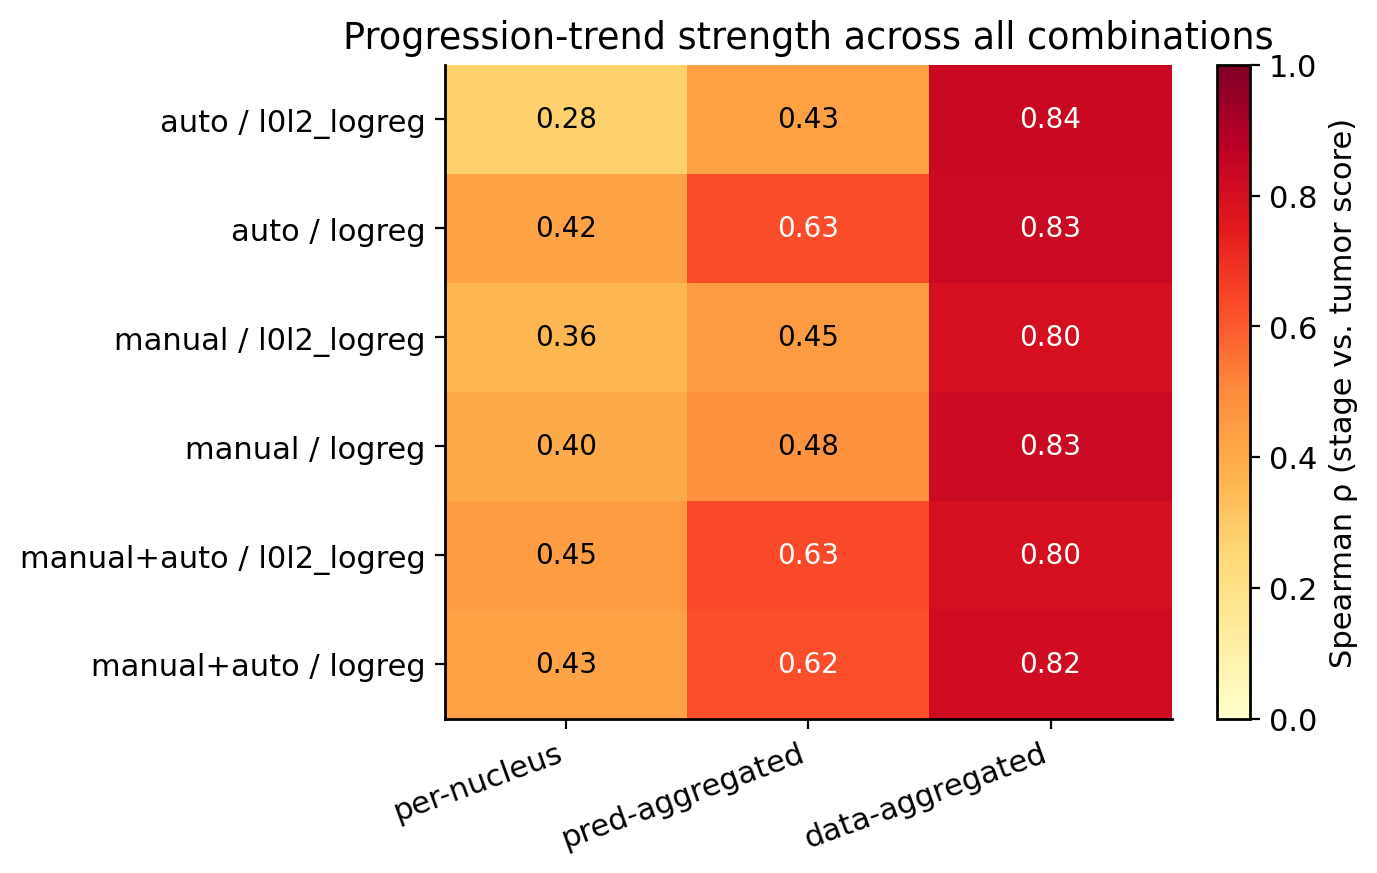

In [6]:
display(Image(filename=str(RESULTS_DIR / 'akps_rho_heatmap.png')))


As in the main classification analysis, **organoid-level aggregation gives the
strongest, most reliable signal** (rho ~0.80-0.84) regardless of training
source or model; per-nucleus scoring is noticeably weaker (rho ~0.28-0.45,
though still highly significant given the large n). This mirrors Sections 3-6
of the main notebook: per-nucleus pseudoreplication adds noise that organoid-level
averaging removes.


## 3. Which features actually drive the trend?

This is the payoff of using `l0l2_logreg`: refitting at the organoid-level for
each training source and reading off the selected features directly.


In [7]:
sel_rows = []
for name, df in train_sets.items():
    agg = _aggregate_organoid(df, extra_cols=['is_tumor'])
    X, y = agg[FEATURE_COLS], agg['is_tumor'].to_numpy()
    m = l0l2_logreg_model()
    m.fit(X, y)
    coeffs = np.asarray(
        m.fit_result.coeff(lambda_0=m.best_lambda, gamma=m.best_gamma, include_intercept=True).todense()
    ).ravel()
    for feat, c in zip(FEATURE_COLS, coeffs[1:]):
        if abs(c) > 1e-10:
            sel_rows.append({'train_set': name, 'feature': feat, 'coefficient': c})
sel_df = pd.DataFrame(sel_rows)
sel_df.to_csv(RESULTS_DIR / 'akps_selected_features.csv', index=False)
sel_df


,train_set,feature,coefficient
0,manual,ellipsoid_axis_minor_um,0.020
1,auto,volume_um,0.585
2,auto,aspect_ratio_minor_per_major,0.820
3,manual+auto,volume_um,1.998
4,manual+auto,solidity,-2.201
5,manual+auto,aspect_ratio_minor_per_major,2.721


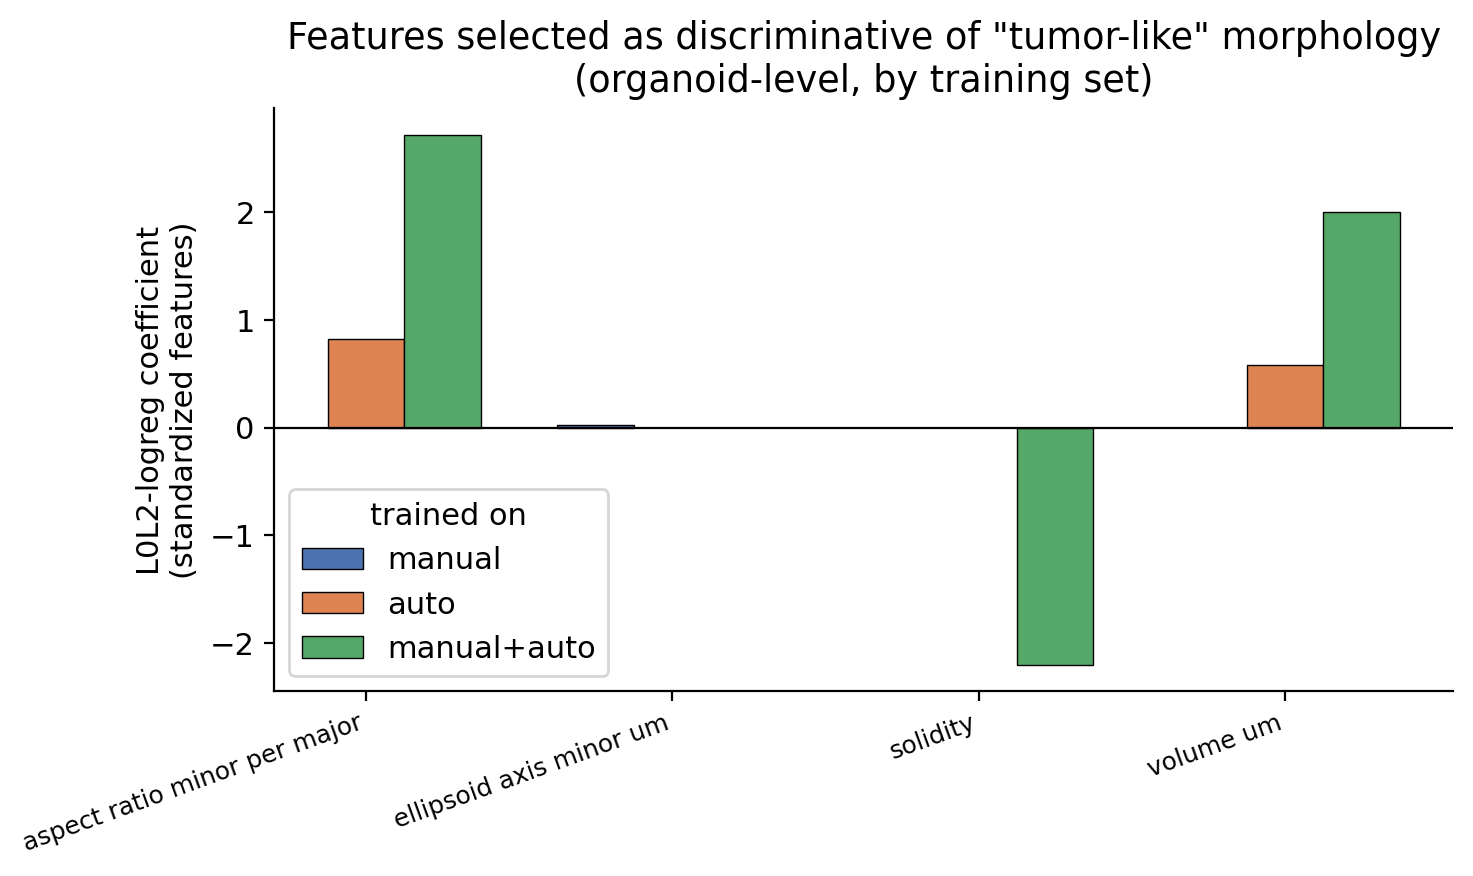

In [8]:
display(Image(filename=str(RESULTS_DIR / 'akps_selected_features_plot.png')))


**`volume_um`** (nucleus volume) and **`aspect_ratio_minor_per_major`**
(elongation) are the recurring selected features across training sources --
directly consistent with the paper's own Section 3.2 finding that nucleus
volume and major-axis-related elongation are the most informative features for
distinguishing cancer cells from benign ones (Fig. 2 of the main draft). This
cross-validates the earlier finding using a completely independent dataset
(the progression series) and an independently-computed feature set (this
notebook's own extractor, not Joshua's original CSV pipeline).

`solidity` also appears when training on the pooled manual+auto set, with a
negative coefficient -- lower solidity (less convex, more irregular nuclear
shape) associated with higher tumor-likeness, consistent with nuclear membrane
irregularity as a malignancy hallmark in the broader cancer-pathology
literature.


## 4. Caveats

- **No manual ground truth for AKPS**: all AKPS scores come from automated
  segmentation only. Section 6 of the main notebook showed manual/auto
  cross-domain transfer is generally reliable (AUC 0.75-1.00), which is the
  basis for trusting these scores, but it is not a guarantee for this specific
  dataset.
- **AKPS spacing assumption**: no pixel-spacing metadata is embedded in the raw
  AKPS TIFFs; all 220 masks are confirmed 40x-objective from their filenames,
  so 0.324 um/px (matching the P021N/P013T 40x calibration) was assumed rather
  than measured directly. Worth confirming with the imaging team.
- **This is a *transfer* test, not a from-scratch progression classifier.** The
  "tumor score" is only ever trained to distinguish P021N vs. P013T; a
  monotonic trend across AKPS stages is consistent with (but doesn't prove)
  that the *same* morphological program drives both healthy-to-tumor and
  the mutational progression. A model trained directly on AKPS labels
  (ordinal or 5-way classification) would test that more directly and is a
  natural next step.
- **Organoid counts per line are modest** (40-50 organoids per line, but each
  averaged from many nuclei) -- enough for the strong Spearman trends seen
  here, but individual-organoid outliers can still move a line's mean
  noticeably (see the point spread in Figure 1).


## 5. Experiment B — a progression classifier trained directly on AKPS

Section 2-3 above test *transfer*: does a P021N/P013T-trained "tumor score"
happen to track AKPS progression? This section asks the more direct question:
**trained only on AKPS data itself, how well can morphology features order or
classify the 5 mutational stages?** This is closer to what the paper's own
Section 3.4/3.5 wants -- independent of whether the healthy-vs-tumor signal
transfers at all.

Two complementary views, both at the organoid level (established as the
cleanest signal throughout this investigation), evaluated with proper 5-fold
stratified cross-validation (not train/apply, since AKPS itself has enough
organoids -- 220 -- to support real held-out evaluation):

- **Sparse ordinal regression** (`fastsparsegams`, L0L2-constrained, squared-error
  loss): treats stage NCO->AKPS as a continuous target (0..4) and finds a small
  set of features whose linear combination best orders organoids along it.
- **Multinomial logistic regression** (plain, not sparse): a reference view of
  raw 5-class separability via a confusion matrix -- shows *which* adjacent
  stages are hardest to tell apart, not just an aggregate accuracy number.


In [9]:
from analysis.akps_stage_classifier import prep_organoid_level, cv_evaluate, fit_full_and_select

agg_akps = prep_organoid_level(akps)
fold_results, agg_preds = cv_evaluate(agg_akps)
fold_results.to_csv(RESULTS_DIR / 'akps_stage_cv_folds.csv', index=False)
agg_preds.to_csv(RESULTS_DIR / 'akps_stage_oof_predictions.csv', index=False)
fold_results


,fold,reg_spearman,reg_pearson,reg_mae,clf_accuracy,n_selected_features
0,0,0.843,0.844,0.618,0.705,4
1,1,0.833,0.824,0.649,0.659,5
2,2,0.798,0.796,0.702,0.591,5
3,3,0.866,0.879,0.563,0.682,5
4,4,0.894,0.889,0.513,0.727,5


In [10]:
print(f"Ordinal regression -- CV Spearman rho: {fold_results['reg_spearman'].mean():.3f} +/- {fold_results['reg_spearman'].std():.3f}")
print(f"Ordinal regression -- CV MAE (stage units): {fold_results['reg_mae'].mean():.3f}")
print(f"5-class classifier -- CV accuracy: {fold_results['clf_accuracy'].mean():.3f}  (chance = 0.20)")


Ordinal regression -- CV Spearman rho: 0.847 +/- 0.036
Ordinal regression -- CV MAE (stage units): 0.609
5-class classifier -- CV accuracy: 0.673  (chance = 0.20)


### Figure 4 — out-of-fold predicted stage (left) and 5-class confusion matrix (right)

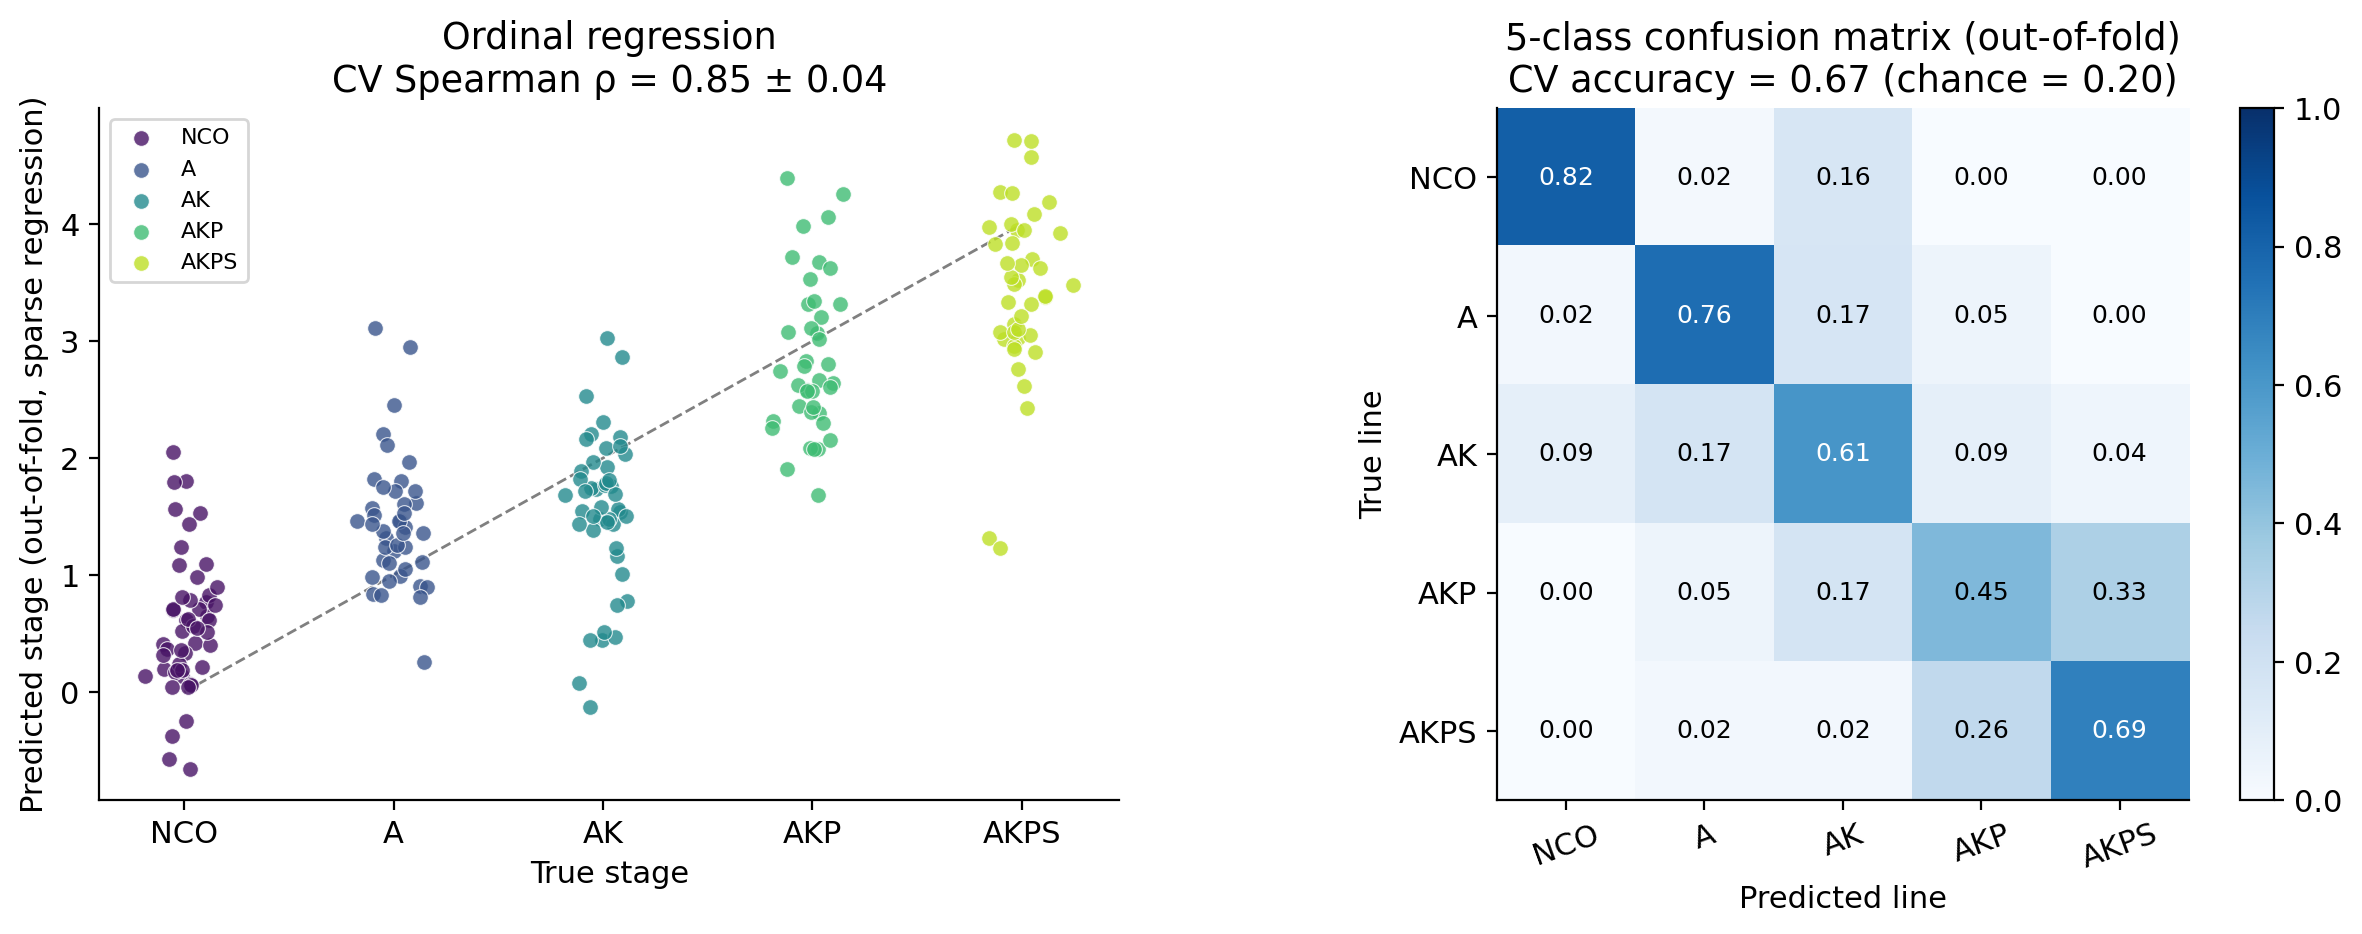

In [11]:
display(Image(filename=str(RESULTS_DIR / 'akps_stage_classifier_plot.png')))


**Both views agree the progression axis is strongly recoverable from
morphology alone, purely from AKPS's own data** -- held-out Spearman rho
~0.85 for the ordinal regression, and 67% 5-class accuracy against a 20%
chance baseline. The confusion matrix shows the expected pattern: most
confusion is between **adjacent** stages (e.g. AK vs. A, AKP vs. AKPS) rather
than distant ones (NCO is rarely confused with AKPS) -- exactly what you'd
expect if morphology changes gradually along the real mutational path rather
than in discrete jumps.


### Figure 5 — features selected by the sparse ordinal regression (full-data fit)

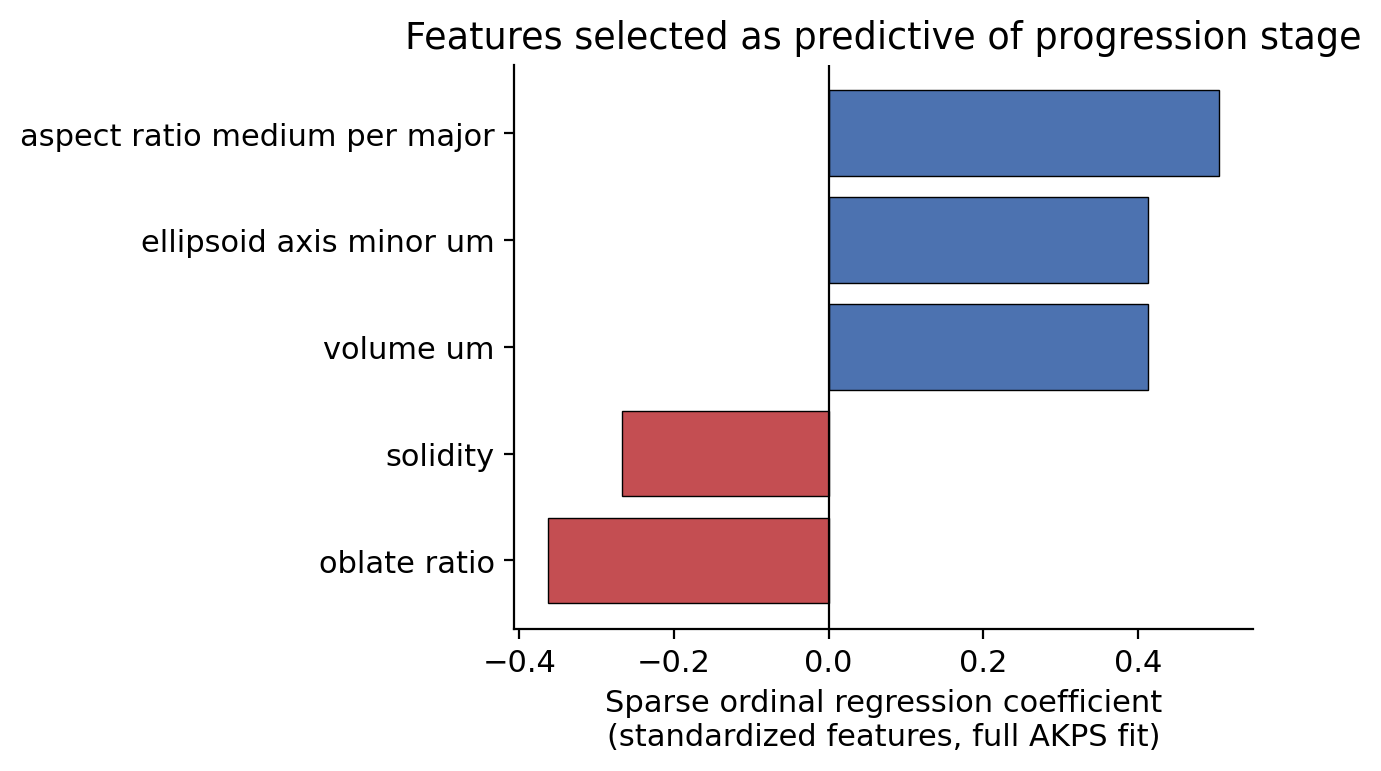

,feature,coefficient
4,oblate_ratio,-0.363
1,solidity,-0.267
0,volume_um,0.413
2,ellipsoid_axis_minor_um,0.414
3,aspect_ratio_medium_per_major,0.506


In [12]:
reg_full, selected_stage_features = fit_full_and_select(agg_akps)
sel_stage_df = pd.DataFrame(
    [{'feature': f, 'coefficient': c} for f, c in selected_stage_features.items()]
).sort_values('coefficient')
sel_stage_df.to_csv(RESULTS_DIR / 'akps_stage_selected_features.csv', index=False)
display(Image(filename=str(RESULTS_DIR / 'akps_stage_selected_features_plot.png')))
sel_stage_df


**`volume_um` again comes out as a top positive predictor** -- the same
feature independently selected in Section 3's transfer experiment (all three
training sources) and in the paper's own Section 3.2 finding (Fig. 2).
Finding it a *third* time here, from a completely different model (regression
vs. classification) trained on a completely different dataset (AKPS itself,
not P021N/P013T), is a strong triangulation: nucleus volume is genuinely the
most robust single morphological correlate of CRC progression severity in
this system, not an artifact of any one dataset or method.

`ellipsoid_axis_minor_um` and `aspect_ratio_medium_per_major` (both positive)
point toward increasing nuclear size/elongation with progression; `solidity`
and `oblate_ratio` (both negative) point toward decreasing convexity/increasing
shape irregularity -- consistent with nuclear-envelope irregularity as a
malignancy hallmark, and with what Section 3's `manual+auto` model also
selected (`solidity`, negative).


## 6. Combined conclusion (Experiments A + B)

Two independent lines of evidence -- transferring a P021N/P013T classifier
(Experiment A) and training fresh on AKPS itself (Experiment B) -- agree:
**nuclear morphology, especially volume and elongation/shape-irregularity
features, tracks the real mutational progression from normal colon organoid
to the fully mutated AKPS line.** This isn't just consistent with the paper's
healthy-vs-tumor finding (Fig. 2) -- it extends it to a genuine dose-response
across the actual CIN pathway, which is the more mechanistically interesting
claim for the lamin-expression story in Section 3.5 of the paper draft.
